<a href="https://colab.research.google.com/github/emurlu024/capstone/blob/old-NRM/Newton_Raphson_Finals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Newton Raphson Final Simulations + Figures

**Simulation 1: Currently Hazardous**

    NEO: 2024 YR4

Parameters: (source - NASA & SBDB)
- Eccentricity --> **ecc** (e): 0.66426900
- Semi-major axis --> **sm_axis** (a): 2.54000858 AU
- Inclination --> **inc** (i): 3.45326192°
- Longitude of ascending node --> **asc_node** (Ω): 271.41230059°
- Perihelion --> **p_helion** (ω): 134.64151115°
- Mean anomaly --> **mean** (M₀): 351.07992528°

      +0.1% velocity (to NEO)

Code below:

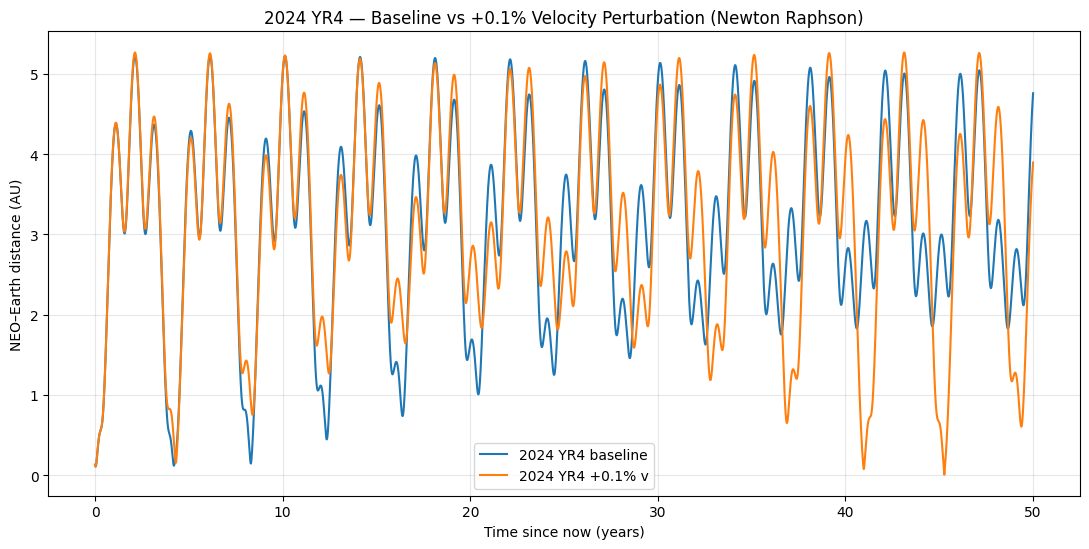

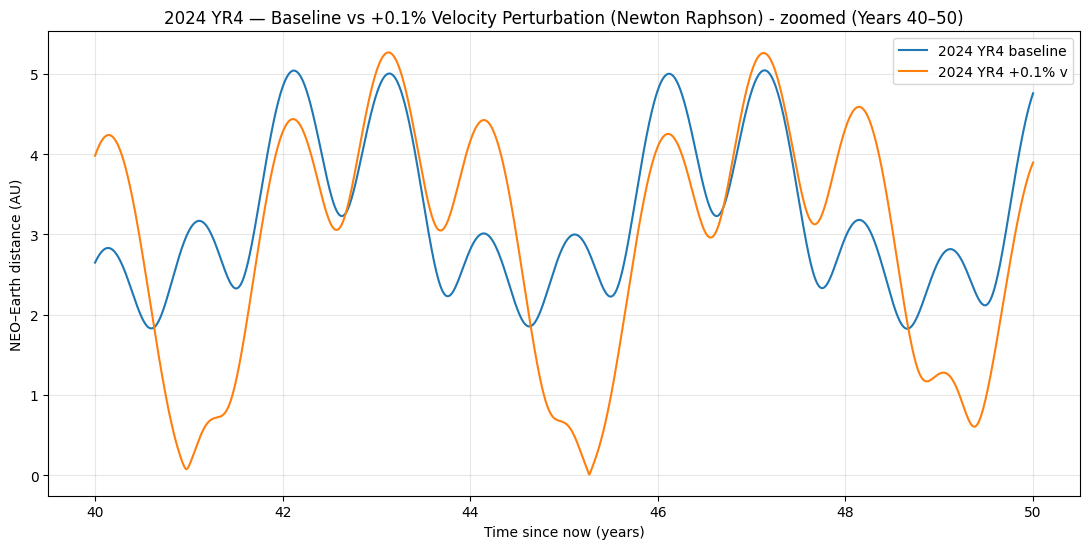


-------------------------MINIMUM DISTANCE REPORT--------------------------
2024 YR4 – Min Earth Distance (baseline):  15907824.24 km at year 0.03
2024 YR4 – Min Earth Distance (+0.1% v):   885407.11 km at year 45.27
--------------------------------------------------------------------------


In [ ]:
#2024 YR4 with +0.1% on NEO's velocity
#Newton Raphson Method

#imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#constants
AU = 1.495978707e11          #[m] Astronomical Unit
DAY = 86400.0                #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth parameters (for distance reference)
mu_earth = 3.986004418e14    #[m^3/s^2] GM⊕ (not used, used in integrator methods)
r_earth_mean = AU            #[m] --> 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s]

#2024 YR4 orbital parameters
ecc = 0.66426900              #eccentricity (e)
sm_axis = 2.54000858          #semi-major axis (a) [AU]
inc = 3.45326192              #inclination (i) [deg]
asc_node = 271.41230059       #longitude of ascending node (Ω) [deg]
p_helion = 134.64151115       #argument of perihelion (ω) [deg]
mean = 351.07992528           #mean anomaly (M) [deg]

#degrees to radians
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#------------------------------------------------------------------------------------
#Kepler --> M = E - e*sin(E) --> orbital conversions
  #for eccentric anomaly E
  #Newton Raphson method
def newtonRaphson(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E
  #------------------------------------------------------------------------------------

    #cartisan state --> heliocentric, inertial
def elements_to_state(a, e, i, Omega, omega, M, mu):
    E = newtonRaphson(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW --> IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

  #2 body ODE (Sun-centered)
def two_body_rhs(t, y, mu):
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#initial conditions (t = now)
  #baseline
r_neo0, v_neo0 = elements_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #perturbed: +0.1% to velocity magnitude (same direction)
      #+0.1%
v_neo0_pert = v_neo0 * 1.001

  #Earth baseline
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

#x-axis set up, time line
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#propagation (Sun-centered two-body)
  #baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #positionals
rN = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE = sol_earth.y[:3].T

#distance calc
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

#graph — full 50-year, graph 1
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="2024 YR4 baseline")
plt.plot(time_years, dist_pert_AU, label="2024 YR4 +0.1% v")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2024 YR4 — Baseline vs +0.1% Velocity Perturbation (Newton Raphson)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#Zoom plot, graph 2 (to see if it hits within the cut off, atmosphere)
mask = (time_years >= 40) & (time_years <= 50)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="2024 YR4 baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], label="2024 YR4 +0.1% v")
plt.xlabel("Time since now (years)") #october - november 2025
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2024 YR4 — Baseline vs +0.1% Velocity Perturbation (Newton Raphson) - zoomed (Years 40–50)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert AU distances to km
dist_base_km = dist_base_AU * AU / 1000.0
dist_pert_km = dist_pert_AU * AU / 1000.0

    #find minimum distance (y-axis)
idx_min_base = np.argmin(dist_base_km)
idx_min_pert = np.argmin(dist_pert_km)

    #time (years) at min (x-axis)
t_min_base_years = time_years[idx_min_base]
t_min_pert_years = time_years[idx_min_pert]

print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
print(f"2024 YR4 – Min Earth Distance (baseline):  {dist_base_km[idx_min_base]:.2f} km "f"at year {t_min_base_years:.2f}")
print(f"2024 YR4 – Min Earth Distance (+0.1% v):   {dist_pert_km[idx_min_pert]:.2f} km "f"at year {t_min_pert_years:.2f}")
print("--------------------------------------------------------------------------")


    +0.5% velocity (to NEO)

Code below:

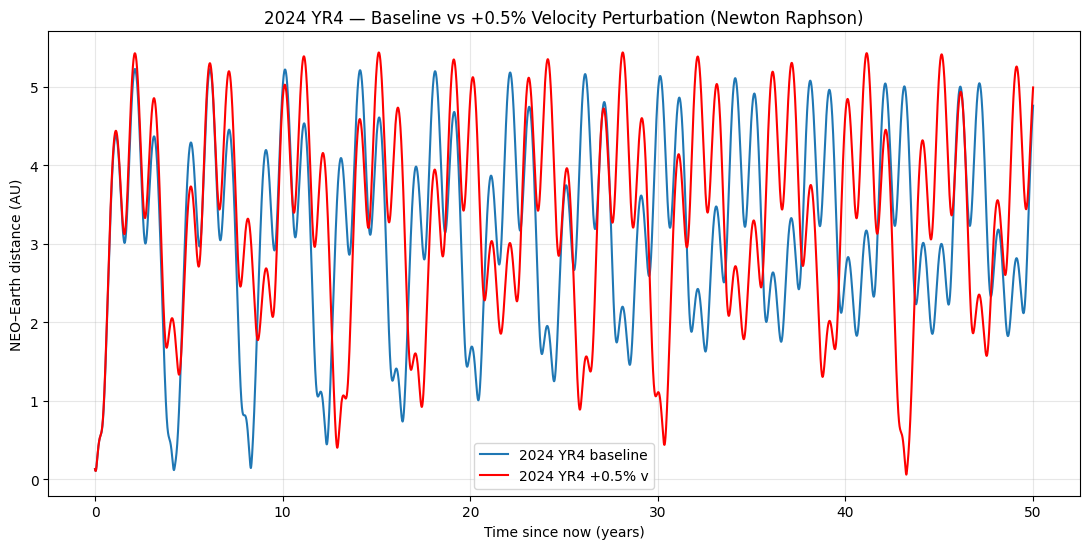

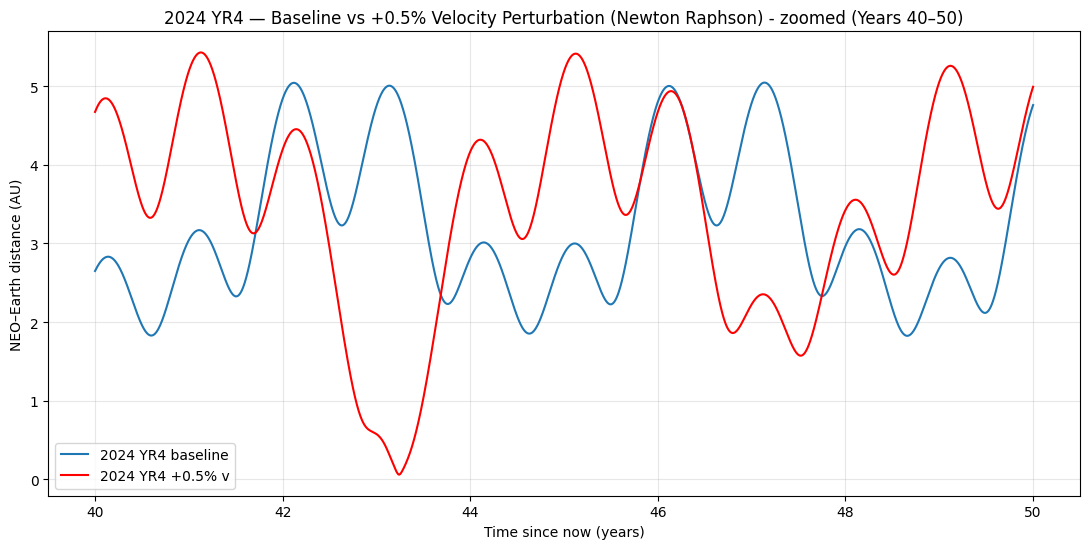


-------------------------MINIMUM DISTANCE REPORT--------------------------
2024 YR4 – Min Earth Distance (baseline):  15907824.24 km at year 0.03
2024 YR4 – Min Earth Distance (+0.5% v):   8895575.63 km at year 43.24
--------------------------------------------------------------------------


In [ ]:
#2024 YR4 with +0.5% on NEO's velocity
#Newton Raphson Method

#imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#constants
AU = 1.495978707e11          #[m] Astronomical Unit
DAY = 86400.0                #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth parameters (for distance reference)
mu_earth = 3.986004418e14    #[m^3/s^2] GM⊕ (not used, used in integrator methods)
r_earth_mean = AU            #[m] --> 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s]

#2024 YR4 orbital parameters (same as +0.1%)
ecc = 0.66426900              #eccentricity (e)
sm_axis = 2.54000858          #semi-major axis (a) [AU]
inc = 3.45326192              #inclination (i) [deg]
asc_node = 271.41230059       #longitude of ascending node (Ω) [deg]
p_helion = 134.64151115       #argument of perihelion (ω) [deg]
mean = 351.07992528           #mean anomaly (M) [deg]

#degrees to radians
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#------------------------------------------------------------------------------------
#Kepler --> M = E - e*sin(E) --> orbital conversions
  #for eccentric anomaly E
  #Newton Raphson method
def newtonRaphson(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E
  #------------------------------------------------------------------------------------

    #cartisan state --> heliocentric, inertial
def elements_to_state(a, e, i, Omega, omega, M, mu):
    E = newtonRaphson(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW --> IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

  #2 body ODE (Sun-centered)
def two_body_rhs(t, y, mu):
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#initial conditions (t = now)
  #baseline
r_neo0, v_neo0 = elements_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #perturbed: +0.5% to velocity magnitude (same direction)
      #+0.5%
v_neo0_pert = v_neo0 * 1.005

  #Earth baseline
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

#x-axis set up, time line
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#propagation (Sun-centered two-body)
  #baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)),args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)),args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)),args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #positionals
rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE = sol_earth.y[:3].T

#distance calc
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

#graph — full 50-year, graph 1
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="2024 YR4 baseline")
plt.plot(time_years, dist_pert_AU, color = 'red', label="2024 YR4 +0.5% v")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2024 YR4 — Baseline vs +0.5% Velocity Perturbation (Newton Raphson)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#Zoom plot, graph 2 (to see if it hits within the cut off, atmosphere)
mask = (time_years >= 40) & (time_years <= 50)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="2024 YR4 baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], color = 'red', label="2024 YR4 +0.5% v")
plt.xlabel("Time since now (years)") #october - november 2025
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2024 YR4 — Baseline vs +0.5% Velocity Perturbation (Newton Raphson) - zoomed (Years 40–50)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert AU distances to km
dist_base_km = dist_base_AU * AU / 1000.0
dist_pert_km = dist_pert_AU * AU / 1000.0

    #find minimum distance (y-axis)
idx_min_base = np.argmin(dist_base_km)
idx_min_pert = np.argmin(dist_pert_km)

    #time (years) at min (x-axis)
t_min_base_years = time_years[idx_min_base]
t_min_pert_years = time_years[idx_min_pert]

print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
print(f"2024 YR4 – Min Earth Distance (baseline):  {dist_base_km[idx_min_base]:.2f} km "f"at year {t_min_base_years:.2f}")
print(f"2024 YR4 – Min Earth Distance (+0.5% v):   {dist_pert_km[idx_min_pert]:.2f} km "f"at year {t_min_pert_years:.2f}")
print("--------------------------------------------------------------------------")


**Simulation 2: Could Become Hazardous**

    NEO: 2000 SG344

Parameters: (source -  JPL Horizons & SBDB)
- Eccentricity --> **ecc** (e): 0.06696
- Semi-major axis --> **sm_axis** (a): 0.97744 AU
- Inclination --> **inc** (i): 0.112°
- Longitude of ascending node --> **asc_node** (Ω): 191.91°
- Perihelion --> **p_helion** (ω): 275.35°
- Mean anomaly --> **mean** (M₀): 35.68°

      +0.1% velocity (to NEO)

Code below:

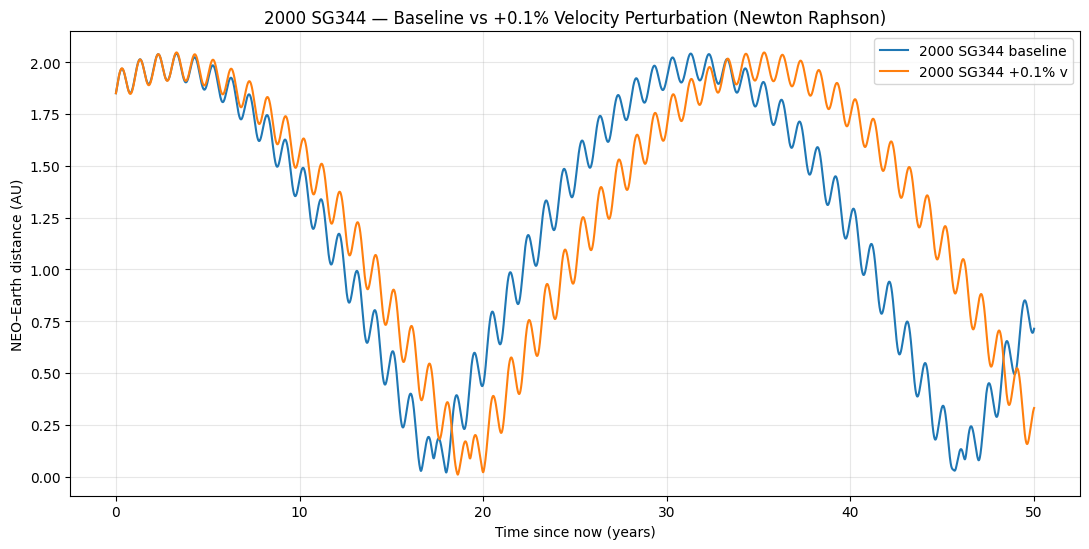

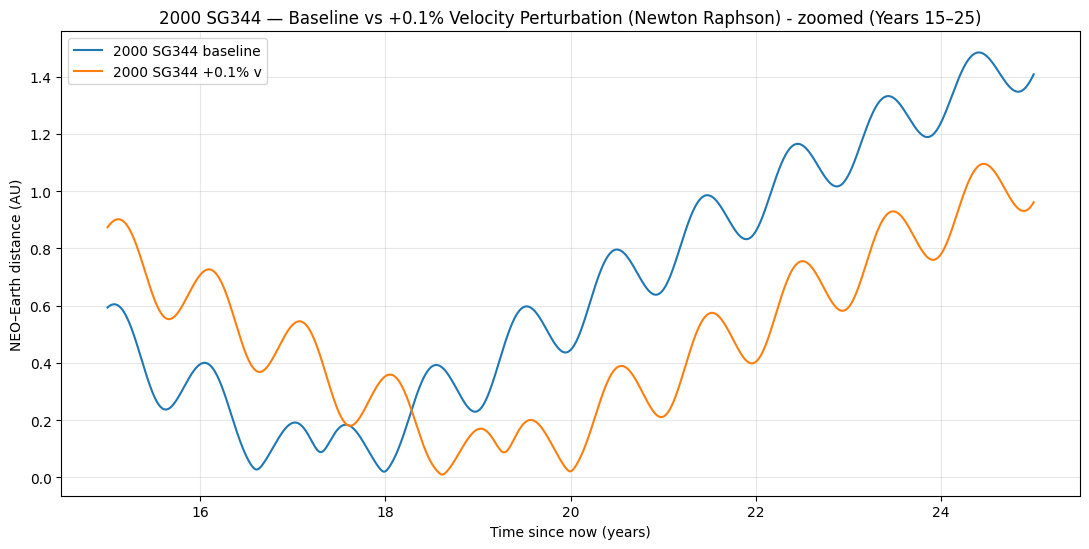


-------------------------MINIMUM DISTANCE REPORT--------------------------
2000 SG344 – Min Earth Distance (baseline):  2943067.57 km at year 17.99
2000 SG344 – Min Earth Distance (+0.1% v):   1407601.71 km at year 18.62
--------------------------------------------------------------------------


In [ ]:
#2000 SG344 with +0.1% on NEO's velocity
#Newton Raphson Method

#imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#constants
AU = 1.495978707e11          #[m] Astronomical Unit
DAY = 86400.0                #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth parameters (for distance reference)
mu_earth = 3.986004418e14    #[m^3/s^2] GM⊕ (not used, used in integrator methods)
r_earth_mean = AU            #[m] --> 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s]

#2000 SG344 orbital parameters
ecc = 0.06696           #eccentricity (e)
sm_axis = 0.97744       #semi-major axis (a) [AU]
inc = 0.112             #inclination (i) [deg]
asc_node = 191.91       #longitude of ascending node (Ω) [deg]
p_helion = 275.35       #argument of perihelion (ω) [deg]
mean = 35.68            #mean anomaly (M) [deg]

#degrees to radians
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#------------------------------------------------------------------------------------
#Kepler --> M = E - e*sin(E) --> orbital conversions
  #for eccentric anomaly E
  #Newton Raphson method
def newtonRaphson(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E
  #------------------------------------------------------------------------------------

    #cartisan state --> heliocentric, inertial
def elements_to_state(a, e, i, Omega, omega, M, mu):
    E = newtonRaphson(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW --> IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

  #2 body ODE (Sun-centered)
def two_body_rhs(t, y, mu):
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#initial conditions (t = now)
  #baseline
r_neo0, v_neo0 = elements_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #perturbed: +0.1% to velocity magnitude (same direction)
      #+0.1%
v_neo0_pert = v_neo0 * 1.001

  #Earth baseline
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

#x-axis set up, time line
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#propagation (Sun-centered two-body)
  #baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #positionals
rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE  = sol_earth.y[:3].T

#distance calc
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

#graph — full 50-year, graph 1
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="2000 SG344 baseline")
plt.plot(time_years, dist_pert_AU, label="2000 SG344 +0.1% v")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2000 SG344 — Baseline vs +0.1% Velocity Perturbation (Newton Raphson)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#Zoom plot, graph 2 (to see if it hits within the cut off, atmosphere)
mask = (time_years >= 15) & (time_years <= 25)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="2000 SG344 baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], label="2000 SG344 +0.1% v")
plt.xlabel("Time since now (years)") #october - november 2025
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2000 SG344 — Baseline vs +0.1% Velocity Perturbation (Newton Raphson) - zoomed (Years 15–25)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert AU distances to km
dist_base_km = dist_base_AU * AU/1000.0
dist_pert_km = dist_pert_AU * AU/1000.0

    #find minimum distance (y-axis)
idx_min_base = np.argmin(dist_base_km)
idx_min_pert = np.argmin(dist_pert_km)

    #time (years) at min (x-axis)
t_min_base_years = time_years[idx_min_base]
t_min_pert_years = time_years[idx_min_pert]

print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
print(f"2000 SG344 – Min Earth Distance (baseline):  {dist_base_km[idx_min_base]:.2f} km "f"at year {t_min_base_years:.2f}")
print(f"2000 SG344 – Min Earth Distance (+0.1% v):   {dist_pert_km[idx_min_pert]:.2f} km "f"at year {t_min_pert_years:.2f}")
print("--------------------------------------------------------------------------")

    +0.5% velocity (to NEO)

Code below:

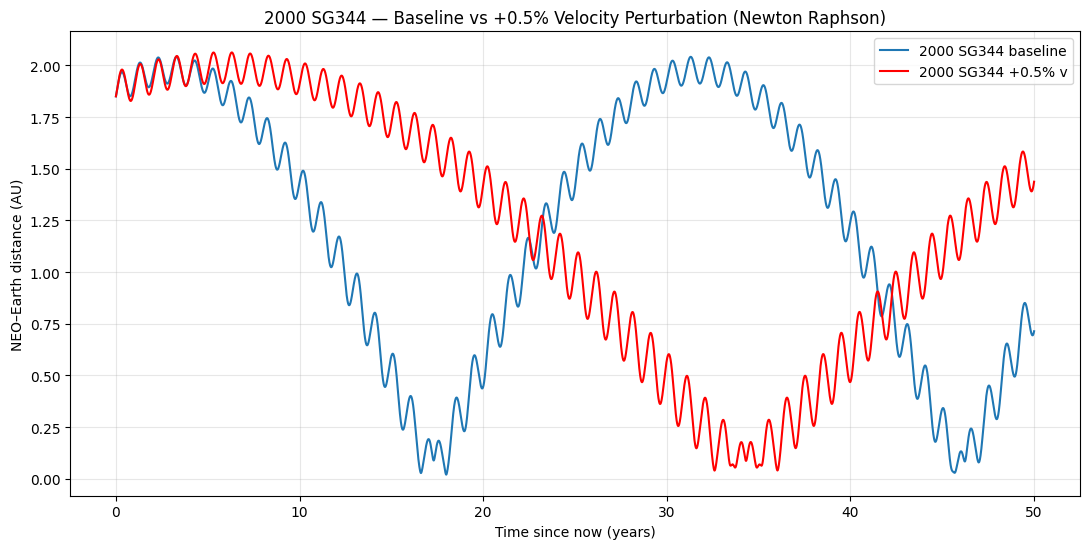

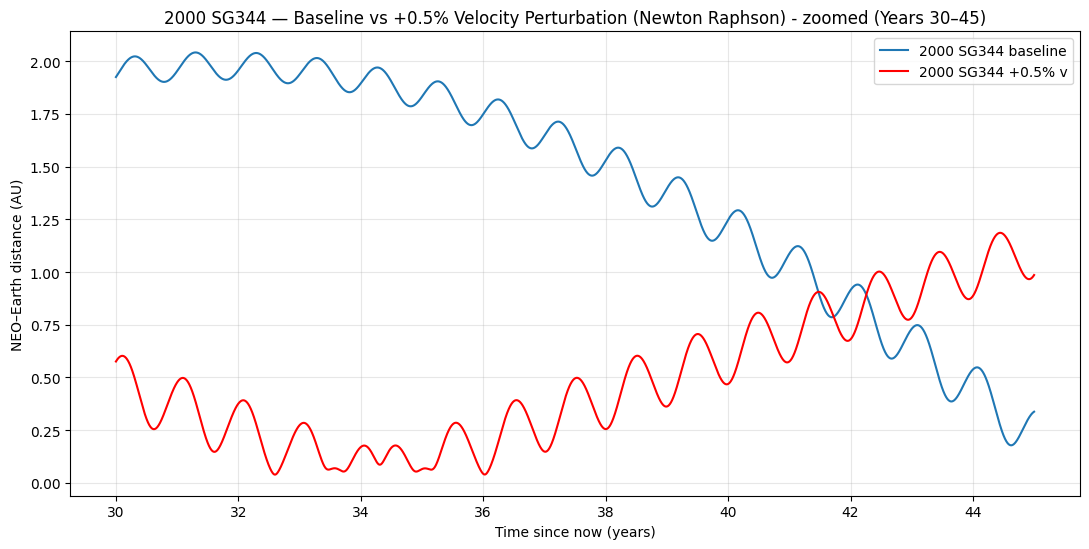


-------------------------MINIMUM DISTANCE REPORT--------------------------
2000 SG344 – Min Earth Distance (baseline):  2943067.57 km at year 17.99
2000 SG344 – Min Earth Distance (+0.5% v):   5864835.75 km at year 32.60
--------------------------------------------------------------------------


In [ ]:
#2000 SG344 with +0.5% on NEO's velocity
#Newton Raphson Method

#imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#constants
AU = 1.495978707e11          #[m] Astronomical Unit
DAY = 86400.0                #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth parameters (for distance reference)
mu_earth = 3.986004418e14    #[m^3/s^2] GM⊕ (not used, used in integrator methods)
r_earth_mean = AU            #[m] --> 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s]

#2000 SG344 orbital parameters
ecc = 0.06696           #eccentricity (e)
sm_axis = 0.97744       #semi-major axis (a) [AU]
inc = 0.112             #inclination (i) [deg]
asc_node = 191.91       #longitude of ascending node (Ω) [deg]
p_helion = 275.35       #argument of perihelion (ω) [deg]
mean = 35.68            #mean anomaly (M) [deg]

#degrees to radians
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#------------------------------------------------------------------------------------
#Kepler --> M = E - e*sin(E) --> orbital conversions
  #for eccentric anomaly E
  #Newton Raphson method
def newtonRaphson(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E
  #------------------------------------------------------------------------------------

    #cartisan state --> heliocentric, inertial
def elements_to_state(a, e, i, Omega, omega, M, mu):
    E = newtonRaphson(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW --> IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

  #2 body ODE (Sun-centered)
def two_body_rhs(t, y, mu):
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#initial conditions (t = now)
  #baseline
r_neo0, v_neo0 = elements_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #perturbed: +0.5% to velocity magnitude (same direction)
      #+0.5%
v_neo0_pert = v_neo0 * 1.005

  #Earth baseline
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

#x-axis set up, time line
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#propagation (Sun-centered two-body)
  #baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #positionals
rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE  = sol_earth.y[:3].T

#distance calc
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

#graph — full 50-year, graph 1
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="2000 SG344 baseline")
plt.plot(time_years, dist_pert_AU, color = 'red', label="2000 SG344 +0.5% v")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2000 SG344 — Baseline vs +0.5% Velocity Perturbation (Newton Raphson)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#Zoom plot, graph 2 (to see if it hits within the cut off, atmosphere)
mask = (time_years >= 30) & (time_years <= 45)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="2000 SG344 baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], color = 'red', label="2000 SG344 +0.5% v")
plt.xlabel("Time since now (years)") #october - november 2025
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2000 SG344 — Baseline vs +0.5% Velocity Perturbation (Newton Raphson) - zoomed (Years 30–45)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert AU distances to km
dist_base_km = dist_base_AU * AU/1000.0
dist_pert_km = dist_pert_AU * AU/1000.0

    #find minimum distance (y-axis)
idx_min_base = np.argmin(dist_base_km)
idx_min_pert = np.argmin(dist_pert_km)

    #time (years) at min (x-axis)
t_min_base_years = time_years[idx_min_base]
t_min_pert_years = time_years[idx_min_pert]

print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
print(f"2000 SG344 – Min Earth Distance (baseline):  {dist_base_km[idx_min_base]:.2f} km "f"at year {t_min_base_years:.2f}")
print(f"2000 SG344 – Min Earth Distance (+0.5% v):   {dist_pert_km[idx_min_pert]:.2f} km "f"at year {t_min_pert_years:.2f}")
print("--------------------------------------------------------------------------")

**Simulation 3: Could Become Hazardous**

    NEO: 2025 FA22

Parameters: (source - JPL SBDB solution JPL#24)
- Eccentricity --> **ecc** (e): 0.4149151053
- Semi-major axis --> **sm_axis** (a): 1.5072249272 AU
- Inclination --> **inc** (i): 7.5470805628°
- Longitude of ascending node --> **asc_node** (Ω): 356.5060673229°
- Perihelion --> **p_helion** (ω): 304.9130604139°
- Mean anomaly --> **mean** (M₀): 309.6876512°

      +0.1% velocity (to NEO)

Code below:

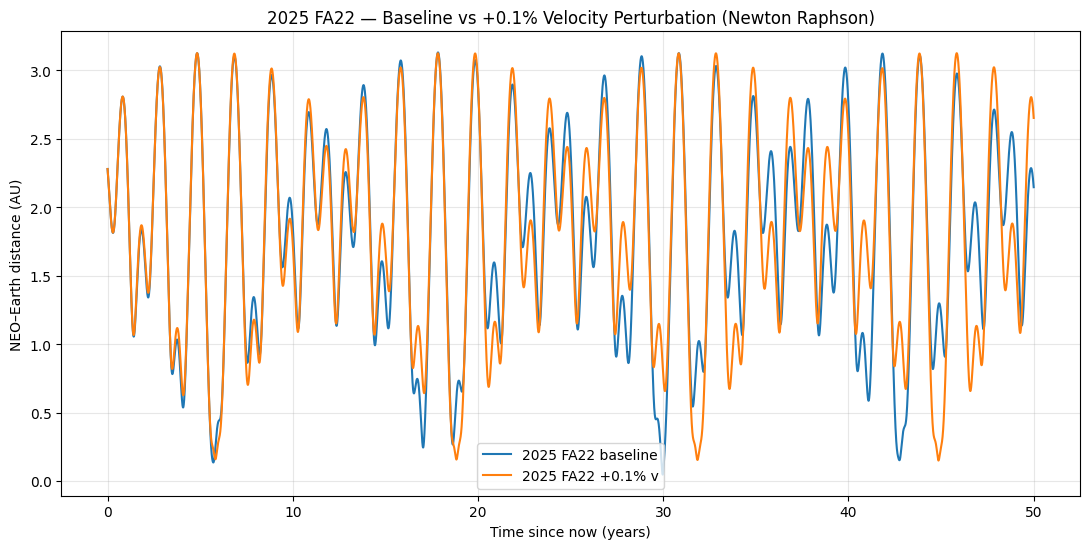

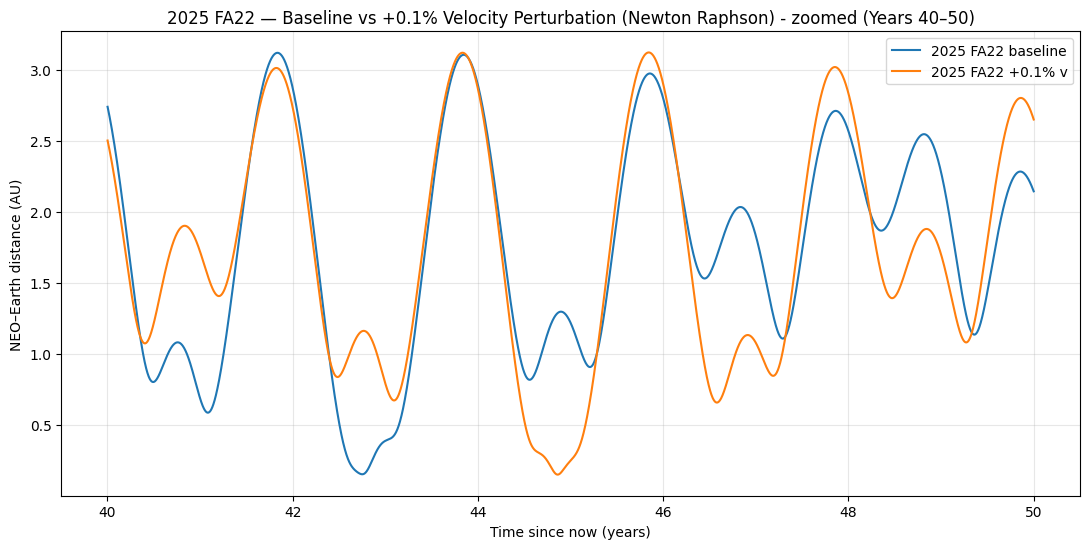


-------------------------MINIMUM DISTANCE REPORT--------------------------
2025 FA22 – Min Earth Distance (baseline):  6962742.09 km at year 29.97
2025 FA22 – Min Earth Distance (+0.1% v):   22328554.67 km at year 44.86
--------------------------------------------------------------------------


In [ ]:
#2025 FA22 with +0.1% on NEO's velocity
#Newton Raphson Method

#imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#constants
AU = 1.495978707e11          #[m] Astronomical Unit
DAY = 86400.0                #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth parameters (for distance reference)
mu_earth = 3.986004418e14    #[m^3/s^2] GM⊕ (not used, used in integrator methods)
r_earth_mean = AU            #[m] --> 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s]

#2025 FA22 orbital parameters
ecc = 0.4149151053              #eccentricity (e)
sm_axis = 1.5072249272          #semi-major axis (a) [AU]
inc = 7.5470805628              #inclination (i) [deg]
asc_node = 356.5060673229       #longitude of ascending node (Ω) [deg]
p_helion = 304.9130604139       #argument of perihelion (ω) [deg]
mean = 309.6876512              #mean anomaly (M) [deg]

#degrees to radians
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#------------------------------------------------------------------------------------
#Kepler --> M = E - e*sin(E) --> orbital conversions
  #for eccentric anomaly E
  #Newton Raphson method
def newtonRaphson(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E
  #------------------------------------------------------------------------------------

    #cartisan state --> heliocentric, inertial
def elements_to_state(a, e, i, Omega, omega, M, mu):
    E = newtonRaphson(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW --> IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

  #2 body ODE (Sun-centered)
def two_body_rhs(t, y, mu):
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#initial conditions (t = now)
  #baseline
r_neo0, v_neo0 = elements_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #perturbed: +0.1% to velocity magnitude (same direction)
      #+0.1%
v_neo0_pert = v_neo0 * 1.001

  #Earth baseline
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

#x-axis set up, time line
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#propagation (Sun-centered two-body)
  #baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #positionals
rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE  = sol_earth.y[:3].T

#distance calc
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

#graph — full 50-year, graph 1
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="2025 FA22 baseline")
plt.plot(time_years, dist_pert_AU, label="2025 FA22 +0.1% v")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2025 FA22 — Baseline vs +0.1% Velocity Perturbation (Newton Raphson)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#Zoom plot, graph 2 (to see if it hits within the cut off, atmosphere)
mask = (time_years >= 40) & (time_years <= 50)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="2025 FA22 baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], label="2025 FA22 +0.1% v")
plt.xlabel("Time since now (years)") #october - november 2025
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2025 FA22 — Baseline vs +0.1% Velocity Perturbation (Newton Raphson) - zoomed (Years 40–50)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert AU distances to km
dist_base_km = dist_base_AU * AU/1000.0
dist_pert_km = dist_pert_AU * AU/1000.0

    #find minimum distance (y-axis)
idx_min_base = np.argmin(dist_base_km)
idx_min_pert = np.argmin(dist_pert_km)

    #time (years) at min (x-axis)
t_min_base_years = time_years[idx_min_base]
t_min_pert_years = time_years[idx_min_pert]

print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
print(f"2025 FA22 – Min Earth Distance (baseline):  {dist_base_km[idx_min_base]:.2f} km "f"at year {t_min_base_years:.2f}")
print(f"2025 FA22 – Min Earth Distance (+0.1% v):   {dist_pert_km[idx_min_pert]:.2f} km "f"at year {t_min_pert_years:.2f}")
print("--------------------------------------------------------------------------")

    +0.5% velocity (to NEO)

Code below:

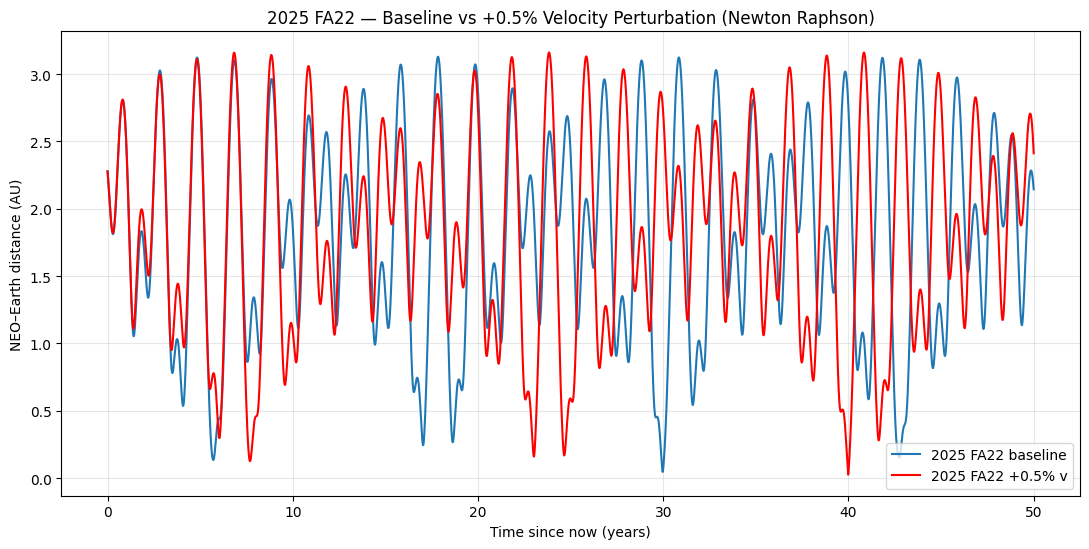

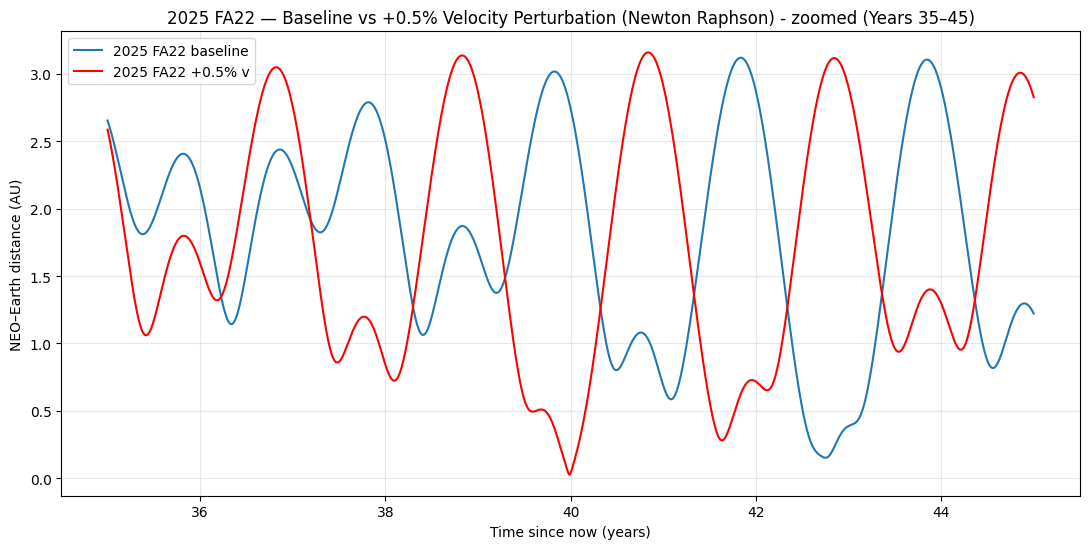


-------------------------MINIMUM DISTANCE REPORT--------------------------
2025 FA22 – Min Earth Distance (baseline):  6962742.09 km at year 29.97
2025 FA22 – Min Earth Distance (+0.5% v):   3958553.16 km at year 39.99
--------------------------------------------------------------------------


In [ ]:
#2025 FA22 with +0.5% on NEO's velocity
#Newton Raphson Method

#imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#constants
AU = 1.495978707e11          #[m] Astronomical Unit
DAY = 86400.0                #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth parameters (for distance reference)
mu_earth = 3.986004418e14    #[m^3/s^2] GM⊕ (not used, used in integrator methods)
r_earth_mean = AU            #[m] --> 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s]

#2025 FA22 orbital parameters
ecc = 0.4149151053              #eccentricity (e)
sm_axis = 1.5072249272          #semi-major axis (a) [AU]
inc = 7.5470805628              #inclination (i) [deg]
asc_node = 356.5060673229       #longitude of ascending node (Ω) [deg]
p_helion = 304.9130604139       #argument of perihelion (ω) [deg]
mean = 309.6876512              #mean anomaly (M) [deg]

#degrees to radians
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#------------------------------------------------------------------------------------
#Kepler --> M = E - e*sin(E) --> orbital conversions
  #for eccentric anomaly E
  #Newton Raphson method
def newtonRaphson(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E
  #------------------------------------------------------------------------------------

    #cartisan state --> heliocentric, inertial
def elements_to_state(a, e, i, Omega, omega, M, mu):
    E = newtonRaphson(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW --> IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

  #2 body ODE (Sun-centered)
def two_body_rhs(t, y, mu):
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#initial conditions (t = now)
  #baseline
r_neo0, v_neo0 = elements_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #perturbed: +0.5% to velocity magnitude (same direction)
      #+0.5%
v_neo0_pert = v_neo0 * 1.005

  #Earth baseline
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

#x-axis set up, time line
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#propagation (Sun-centered two-body)
  #baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #positionals
rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE  = sol_earth.y[:3].T

#distance calc
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

#graph — full 50-year, graph 1
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="2025 FA22 baseline")
plt.plot(time_years, dist_pert_AU, color = 'red', label="2025 FA22 +0.5% v")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2025 FA22 — Baseline vs +0.5% Velocity Perturbation (Newton Raphson)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#Zoom plot, graph 2 (to see if it hits within the cut off, atmosphere)
mask = (time_years >= 35) & (time_years <= 45)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="2025 FA22 baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], color = 'red', label="2025 FA22 +0.5% v")
plt.xlabel("Time since now (years)") #october - november 2025
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2025 FA22 — Baseline vs +0.5% Velocity Perturbation (Newton Raphson) - zoomed (Years 35–45)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert AU distances to km
dist_base_km = dist_base_AU * AU/1000.0
dist_pert_km = dist_pert_AU * AU/1000.0

    #find minimum distance (y-axis)
idx_min_base = np.argmin(dist_base_km)
idx_min_pert = np.argmin(dist_pert_km)

    #time (years) at min (x-axis)
t_min_base_years = time_years[idx_min_base]
t_min_pert_years = time_years[idx_min_pert]

print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
print(f"2025 FA22 – Min Earth Distance (baseline):  {dist_base_km[idx_min_base]:.2f} km "f"at year {t_min_base_years:.2f}")
print(f"2025 FA22 – Min Earth Distance (+0.5% v):   {dist_pert_km[idx_min_pert]:.2f} km "f"at year {t_min_pert_years:.2f}")
print("--------------------------------------------------------------------------")

**Simulation 4: Could Become Hazardous**

    NEO: 101955 Bennu

Parameters: (source - NASA/JPL (SBDB/Horizons))
- Eccentricity --> **ecc** (e): 0.2038
- Semi-major axis --> **sm_axis** (a): 1.1264 AU
- Inclination --> **inc** (i): 6.0349°
- Longitude of ascending node --> **asc_node** (Ω): 2.0609°
- Perihelion --> **p_helion** (ω): 66.2231°
- Mean anomaly --> **mean** (M₀): 101.7039°

      +0.1% velocity (to NEO)

Code below:

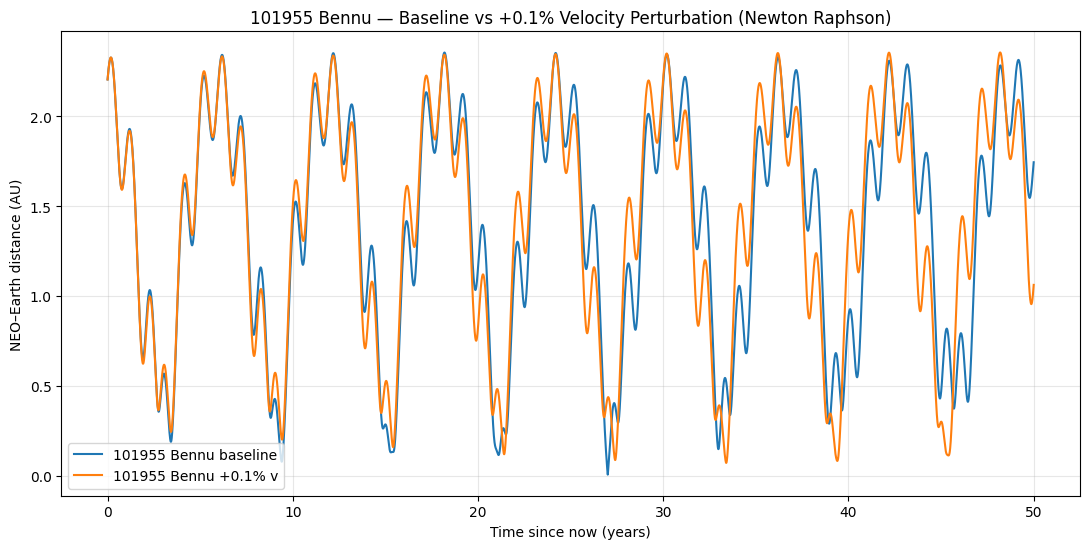

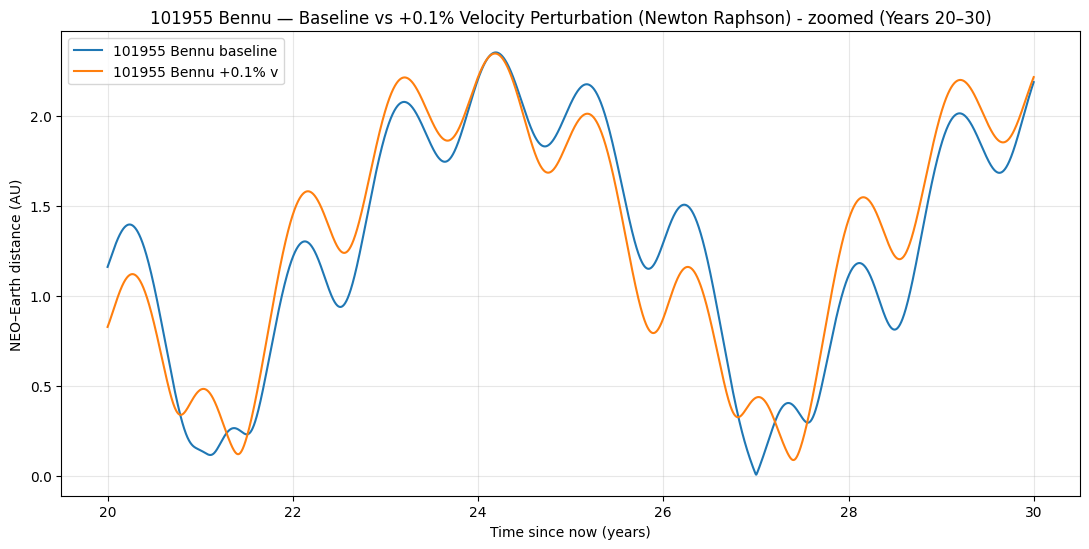


-------------------------MINIMUM DISTANCE REPORT--------------------------
101955 Bennu – Min Earth Distance (baseline):  1021958.91 km at year 27.00
101955 Bennu – Min Earth Distance (+0.1% v):   10743548.94 km at year 33.40
--------------------------------------------------------------------------


In [ ]:
#101955 Bennu with +0.1% on NEO's velocity
#Newton Raphson Method

#imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#constants
AU = 1.495978707e11          #[m] Astronomical Unit
DAY = 86400.0                #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth parameters (for distance reference)
mu_earth = 3.986004418e14    #[m^3/s^2] GM⊕ (not used, used in integrator methods)
r_earth_mean = AU            #[m] --> 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s]

#101955 Bennu orbital parameters
ecc = 0.2038              #eccentricity (e)
sm_axis = 1.1264          #semi-major axis (a) [AU]
inc = 6.0349              #inclination (i) [deg]
asc_node = 2.0609         #longitude of ascending node (Ω) [deg]
p_helion = 66.2231        #argument of perihelion (ω) [deg]
mean = 101.7039           #mean anomaly (M) [deg]

#degrees to radians
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#------------------------------------------------------------------------------------
#Kepler --> M = E - e*sin(E) --> orbital conversions
  #for eccentric anomaly E
  #Newton Raphson method
def newtonRaphson(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E
  #------------------------------------------------------------------------------------

    #cartisan state --> heliocentric, inertial
def elements_to_state(a, e, i, Omega, omega, M, mu):
    E = newtonRaphson(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW --> IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

  #2 body ODE (Sun-centered)
def two_body_rhs(t, y, mu):
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#initial conditions (t = now)
  #baseline
r_neo0, v_neo0 = elements_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #perturbed: +0.1% to velocity magnitude (same direction)
      #+0.1%
v_neo0_pert = v_neo0 * 1.001

  #Earth baseline
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

#x-axis set up, time line
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#propagation (Sun-centered two-body)
  #baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #positionals
rN = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE = sol_earth.y[:3].T

#distance calc
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

#graph — full 50-year, graph 1
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="101955 Bennu baseline")
plt.plot(time_years, dist_pert_AU, label="101955 Bennu +0.1% v")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("101955 Bennu — Baseline vs +0.1% Velocity Perturbation (Newton Raphson)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#Zoom plot, graph 2 (to see if it hits within the cut off, atmosphere)
mask = (time_years >= 20) & (time_years <= 30)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="101955 Bennu baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], label="101955 Bennu +0.1% v")
plt.xlabel("Time since now (years)") #october - november 2025
plt.ylabel("NEO–Earth distance (AU)")
plt.title("101955 Bennu — Baseline vs +0.1% Velocity Perturbation (Newton Raphson) - zoomed (Years 20–30)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert AU distances to km
dist_base_km = dist_base_AU * AU / 1000.0
dist_pert_km = dist_pert_AU * AU / 1000.0

    #find minimum distance (y-axis)
idx_min_base = np.argmin(dist_base_km)
idx_min_pert = np.argmin(dist_pert_km)

    #time (years) at min (x-axis)
t_min_base_years = time_years[idx_min_base]
t_min_pert_years = time_years[idx_min_pert]

print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
print(f"101955 Bennu – Min Earth Distance (baseline):  {dist_base_km[idx_min_base]:.2f} km "f"at year {t_min_base_years:.2f}")
print(f"101955 Bennu – Min Earth Distance (+0.1% v):   {dist_pert_km[idx_min_pert]:.2f} km "f"at year {t_min_pert_years:.2f}")
print("--------------------------------------------------------------------------")


    +0.5% velocity (to NEO)

Code below:

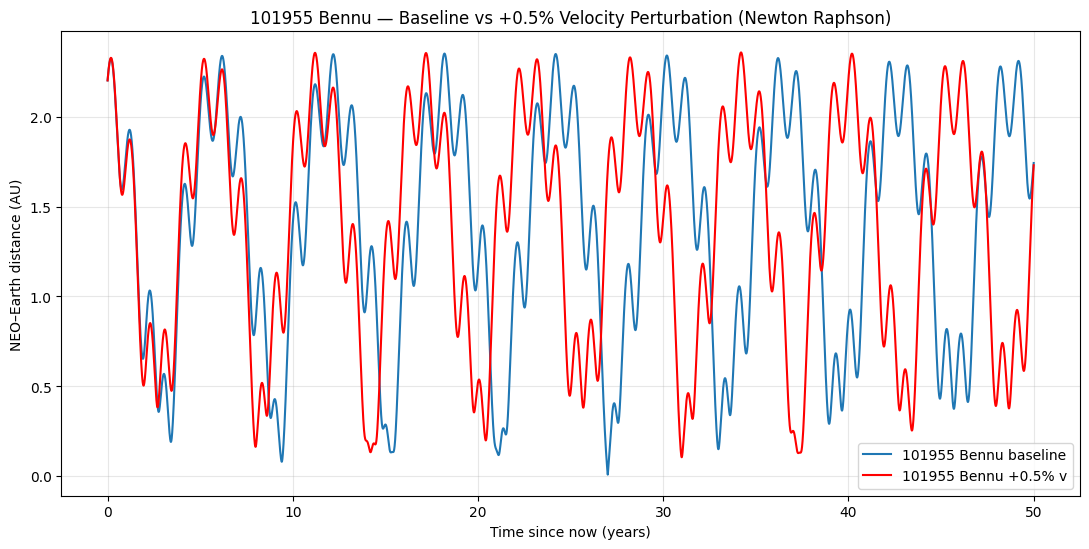

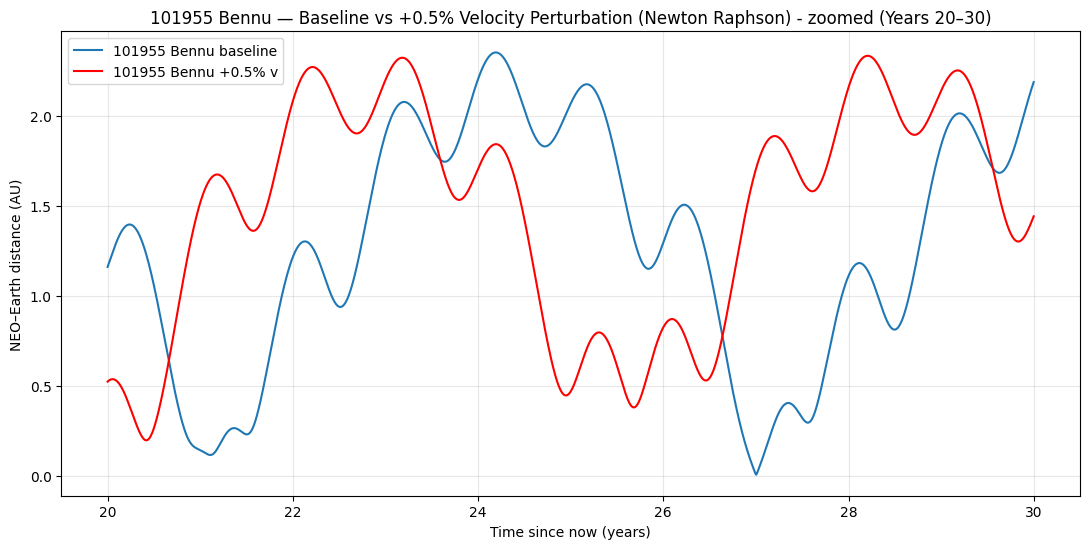


-------------------------MINIMUM DISTANCE REPORT--------------------------
101955 Bennu – Min Earth Distance (baseline):  1021958.91 km at year 27.00
101955 Bennu – Min Earth Distance (+0.5% v):   15463430.43 km at year 31.00
--------------------------------------------------------------------------


In [ ]:
#101955 Bennu with +0.5% on NEO's velocity
#Newton Raphson Method

#imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#constants
AU = 1.495978707e11          #[m] Astronomical Unit
DAY = 86400.0                #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth parameters (for distance reference)
mu_earth = 3.986004418e14    #[m^3/s^2] GM⊕ (not used, used in integrator methods)
r_earth_mean = AU            #[m] --> 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s]

#101955 Bennu orbital parameters
ecc = 0.2038              #eccentricity (e)
sm_axis = 1.1264          #semi-major axis (a) [AU]
inc = 6.0349              #inclination (i) [deg]
asc_node = 2.0609         #longitude of ascending node (Ω) [deg]
p_helion = 66.2231        #argument of perihelion (ω) [deg]
mean = 101.7039           #mean anomaly (M) [deg]

#degrees to radians
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#------------------------------------------------------------------------------------
#Kepler --> M = E - e*sin(E) --> orbital conversions
  #for eccentric anomaly E
  #Newton Raphson method
def newtonRaphson(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E
  #------------------------------------------------------------------------------------

    #cartisan state --> heliocentric, inertial
def elements_to_state(a, e, i, Omega, omega, M, mu):
    E = newtonRaphson(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW --> IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

  #2 body ODE (Sun-centered)
def two_body_rhs(t, y, mu):
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#initial conditions (t = now)
  #baseline
r_neo0, v_neo0 = elements_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #perturbed: +0.5% to velocity magnitude (same direction)
      #+0.5%
v_neo0_pert = v_neo0 * 1.005

  #Earth baseline
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

#x-axis set up, time line
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#propagation (Sun-centered two-body)
  #baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)), args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)), args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #positionals
rN = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE = sol_earth.y[:3].T

#distance calc
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

#graph — full 50-year, graph 1
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="101955 Bennu baseline")
plt.plot(time_years, dist_pert_AU, color = 'red', label="101955 Bennu +0.5% v")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("101955 Bennu — Baseline vs +0.5% Velocity Perturbation (Newton Raphson)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#Zoom plot, graph 2 (to see if it hits within the cut off, atmosphere)
mask = (time_years >= 20) & (time_years <= 30)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="101955 Bennu baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], color = 'red', label="101955 Bennu +0.5% v")
plt.xlabel("Time since now (years)") #october - november 2025
plt.ylabel("NEO–Earth distance (AU)")
plt.title("101955 Bennu — Baseline vs +0.5% Velocity Perturbation (Newton Raphson) - zoomed (Years 20–30)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert AU distances to km
dist_base_km = dist_base_AU * AU / 1000.0
dist_pert_km = dist_pert_AU * AU / 1000.0

    #find minimum distance (y-axis)
idx_min_base = np.argmin(dist_base_km)
idx_min_pert = np.argmin(dist_pert_km)

    #time (years) at min (x-axis)
t_min_base_years = time_years[idx_min_base]
t_min_pert_years = time_years[idx_min_pert]

print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
print(f"101955 Bennu – Min Earth Distance (baseline):  {dist_base_km[idx_min_base]:.2f} km "f"at year {t_min_base_years:.2f}")
print(f"101955 Bennu – Min Earth Distance (+0.5% v):   {dist_pert_km[idx_min_pert]:.2f} km "f"at year {t_min_pert_years:.2f}")
print("--------------------------------------------------------------------------")